# 110 · Chess Siamese

Este notebook aplico ciertas correcciones con respecto al notebook 103_chess_siamese_copy.ipynb.
La necesidad de esto se debe a, una validación confusa, un entrenamiento fallido (val-loss aumenta progresivamente)  entre otros detalles.

## Cambios respecto a 103

1. **Señal centrada en el jugador objetivo**: se generan secuencias solo con jugadas del jugador (no del rival). Esto será una prueba, desconozco el potencial de esto separando el comportamiento de un usuario que no se analiza.
2. **Normalización de perspectiva por color**: si el jugador va con negras, el tablero se espeja para alinear estilo.
3. **Preprocesado correcto de ResNet50**: uso explícito de `preprocess_input`.
4. **Entrenamiento estable**: batches balanceados por jugador + batch-hard triplet + término CE auxiliar.
5. **Evaluación robusta**: centroides, top-k, kNN y análisis de margen intra/inter en true hold-out.


In [28]:
import io
import json
import logging
import math
import random
import re
import sqlite3
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import chess
import chess.pgn
import chess.svg
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import zstandard as zstd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score,
)
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras import Model, layers

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s"
)

SEED = 314159  # PI seed
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.style.use("seaborn-v0_8")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as gpu_err:
            logging.warning("No se pudo activar memory_growth en %s: %s", gpu, gpu_err)
else:
    logging.warning("No se detectó GPU; el entrenamiento usará CPU.")

print(f"TensorFlow {tf.__version__}")

try:
    tf.config.optimizer.set_jit(False)
    print("XLA JIT desactivado para mejorar estabilidad.")
except Exception as jit_err:
    logging.warning("No se pudo desactivar XLA JIT: %s", jit_err)

TensorFlow 2.17.0
XLA JIT desactivado para mejorar estabilidad.


In [29]:
def detect_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "labs").exists():
            return candidate
    raise RuntimeError("No se encontró la raíz del repo (carpeta labs/).")


REPO_ROOT = detect_repo_root()
LABS_DIR = REPO_ROOT / "labs"

import sys

if str(LABS_DIR / "src") not in sys.path:
    sys.path.insert(0, str(LABS_DIR / "src"))

PGN_DATA_DIR = Path("/pgn_data")
INDEX_DB = PGN_DATA_DIR / "index.db"
PLAYERS_DIR = PGN_DATA_DIR / "players"
assert PGN_DATA_DIR.exists(), f"Volumen de datos no montado en {PGN_DATA_DIR}"
assert INDEX_DB.exists(), f"No existe {INDEX_DB}"


@dataclass
class Config:
    event_name: str = "compressed_110"

    # Dataset
    players_count: int = 10
    min_games_in_db: int = 350
    games_per_player: int = 180
    holdout_games_per_player: int = 40
    min_samples_per_player: int = 12

    # Secuencia temporal
    sequence_len: int = 15
    fullmove_start: int = 15
    fullmove_end: int = 60
    image_size: Tuple[int, int] = (192, 192)

    # Entrenamiento
    players_per_batch: int = 5
    samples_per_player: int = 4

    # Se usan como tope; el número real de steps se ajusta dinámicamente
    # según tamaño de TRAIN/VAL para evitar epochs artificialmente largos.
    steps_per_epoch: int = 192
    val_steps: int = 48
    train_passes_per_epoch: float = 1.5
    val_passes_per_epoch: float = 0.75

    epochs: int = 2000
    min_epochs_before_es: int = 200
    early_stop_patience: int = 220
    reduce_lr_patience: int = 80
    validation_freq: int = 1

    learning_rate: float = 3e-6
    min_lr: float = 5e-8
    lr_factor: float = 0.5
    margin: float = 0.06
    ce_weight: float = 0.20
    embedding_dim: int = 256

    # Rendimiento del input pipeline
    sequence_cache_size: int = 128
    fit_workers: int = 1
    fit_use_multiprocessing: bool = False
    fit_max_queue_size: int = 2

    # Split
    validation_fraction: float = 0.2

    # Otros
    seed: int = SEED


CONFIG = Config()
PLY_LABELS = [f"ply{i:02d}" for i in range(1, CONFIG.sequence_len + 1)]

OUTPUT_BASE = LABS_DIR / "notebooks" / "output" / "events" / CONFIG.event_name
TRAIN_PGN_DIR = OUTPUT_BASE / "pgn_train"
TRAIN_BOARD_DIR = OUTPUT_BASE / "board_images"
TRAIN_HEAT_DIR = OUTPUT_BASE / "heatmap_images"

HOLDOUT_PGN_DIR = OUTPUT_BASE / "pgn_holdout"
HOLDOUT_BOARD_DIR = OUTPUT_BASE / "holdout_board_images"
HOLDOUT_HEAT_DIR = OUTPUT_BASE / "holdout_heatmap_images"

for p in [
    TRAIN_PGN_DIR,
    TRAIN_BOARD_DIR,
    TRAIN_HEAT_DIR,
    HOLDOUT_PGN_DIR,
    HOLDOUT_BOARD_DIR,
    HOLDOUT_HEAT_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Repo raíz: {REPO_ROOT}")
print(f"Evento: {CONFIG.event_name}")
print(
    f"Secuencia: {CONFIG.sequence_len} jugadas del jugador [{CONFIG.fullmove_start}, {CONFIG.fullmove_end}]"
)


Repo raíz: /workspace/code
Evento: compressed_110
Secuencia: 15 jugadas del jugador [15, 60]


## 1) Selección de jugadores y extracción PGN (train + hold-out)


In [3]:
def find_zst_path(player_name: str) -> Optional[Path]:
    prefix = player_name[:2].lower()
    candidate = PLAYERS_DIR / prefix / f"{player_name}.pgn.zst"
    if candidate.exists():
        return candidate

    prefix_dir = PLAYERS_DIR / prefix
    if not prefix_dir.exists():
        return None

    target = f"{player_name.lower()}.pgn.zst"
    for file_path in prefix_dir.iterdir():
        if file_path.name.lower() == target:
            return file_path
    return None


def extract_elo_from_zst(zst_path: Path, max_bytes: int = 100_000) -> Optional[int]:
    try:
        dctx = zstd.ZstdDecompressor()
        with open(zst_path, "rb") as f:
            reader = dctx.stream_reader(f)
            text = reader.read(max_bytes).decode("utf-8", errors="replace")

        values: List[int] = []
        for line in text.splitlines():
            line = line.strip()
            if line.startswith("[WhiteElo") or line.startswith("[BlackElo"):
                try:
                    elo = int(line.split('"')[1])
                except (IndexError, ValueError):
                    continue
                if 400 <= elo <= 3500:
                    values.append(elo)

        if values:
            return int(np.median(values))
    except Exception:
        return None
    return None


def select_diverse_elo_players(
    num_players: int,
    min_games: int,
    seed: int,
    candidate_pool: int = 250,
) -> pd.DataFrame:
    rng = random.Random(seed)

    conn = sqlite3.connect(str(INDEX_DB))
    try:
        df = pd.read_sql_query(
            f"SELECT name, total_games FROM players "
            f"WHERE total_games >= {min_games} "
            f"ORDER BY RANDOM() LIMIT {candidate_pool * 3}",
            conn,
        )
    finally:
        conn.close()

    records = []
    for _, row in df.iterrows():
        zst_path = find_zst_path(row["name"])
        if zst_path is None:
            continue
        elo = extract_elo_from_zst(zst_path)
        if elo is None:
            continue
        records.append(
            {
                "player": row["name"],
                "total_games": int(row["total_games"]),
                "elo": int(elo),
                "zst_path": str(zst_path),
            }
        )
        if len(records) >= candidate_pool:
            break

    cands = pd.DataFrame(records)
    if cands.empty:
        raise RuntimeError("No se encontraron candidatos válidos.")

    bins = list(range(600, 3000, 200))
    cands["elo_bin"] = pd.cut(cands["elo"], bins=bins, labels=False)

    selected_rows = []
    available_bins = sorted(cands["elo_bin"].dropna().unique())
    rng.shuffle(available_bins)

    for elo_bin in available_bins:
        if len(selected_rows) >= num_players:
            break
        group = cands[cands["elo_bin"] == elo_bin]
        picked = group.sample(1, random_state=seed).iloc[0]
        selected_rows.append(picked)

    if len(selected_rows) < num_players:
        used = {r["player"] for r in selected_rows}
        remainder = cands[~cands["player"].isin(used)]
        extra = remainder.sample(
            min(num_players - len(selected_rows), len(remainder)), random_state=seed
        )
        for _, row in extra.iterrows():
            selected_rows.append(row)

    out = pd.DataFrame(selected_rows).sort_values("elo").reset_index(drop=True)
    return out


def split_pgn_games(pgn_text: str) -> List[str]:
    games: List[str] = []
    current: List[str] = []

    for line in pgn_text.splitlines():
        if line.startswith("[Event ") and current:
            games.append("\n".join(current).strip())
            current = []
        current.append(line)

    if current:
        games.append("\n".join(current).strip())

    return [g for g in games if g]


def decompress_player_pgn_slice(
    player_name: str,
    zst_path: str,
    output_dir: Path,
    start_game_idx: int,
    max_games: int,
) -> Tuple[Path, int]:
    output_dir.mkdir(parents=True, exist_ok=True)
    out_path = output_dir / f"{player_name}.pgn"

    dctx = zstd.ZstdDecompressor()
    with open(zst_path, "rb") as f:
        reader = dctx.stream_reader(f)
        full_text = reader.read().decode("utf-8", errors="replace")

    games = split_pgn_games(full_text)
    selected = games[start_game_idx : start_game_idx + max_games]

    with open(out_path, "w", encoding="utf-8") as f:
        f.write("\n\n".join(selected))

    return out_path, len(selected)

## 2) Generación de imágenes(jugador objetivo + perspectiva normalizada)


In [4]:
def board_to_rgb_array(board: chess.Board, size: int = 400) -> np.ndarray:
    import cairosvg

    svg = chess.svg.board(board=board, size=size, coordinates=False)
    png_bytes = cairosvg.svg2png(bytestring=svg.encode("utf-8"))
    png_array = np.frombuffer(png_bytes, dtype=np.uint8)
    bgr = cv2.imdecode(png_array, cv2.IMREAD_COLOR)
    if bgr is None:
        raise RuntimeError("No se pudo renderizar el tablero a imagen.")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def parse_clock_time(clk_string: str) -> Optional[float]:
    if not clk_string:
        return None

    hms = re.match(r"(\d+):(\d+):(\d+)", clk_string)
    if hms:
        h, m, s = map(int, hms.groups())
        return float(h * 3600 + m * 60 + s)

    ms = re.match(r"(\d+):(\d+)", clk_string)
    if ms:
        m, s = map(int, ms.groups())
        return float(m * 60 + s)

    return None


def extract_time_control(game: chess.pgn.Game) -> Optional[Tuple[int, int]]:
    tc_header = game.headers.get("TimeControl", "")
    match = re.match(r"(\d+)\+(\d+)", tc_header)
    if not match:
        return None
    base, inc = map(int, match.groups())
    return base, inc


def extract_decision_seconds_by_halfmove(
    game: chess.pgn.Game,
) -> Dict[int, Dict[str, float]]:
    tc = extract_time_control(game)
    if tc is None:
        return {}

    initial_seconds, increment = tc
    prev_clock = {"white": None, "black": None}

    board = game.board()
    move_idx = 0
    out: Dict[int, Dict[str, float]] = {}

    for node in game.mainline():
        move_idx += 1
        color = "white" if board.turn == chess.WHITE else "black"
        board.push(node.move)

        clk_match = re.search(r"\[%clk\s+(\d+:\d+:\d+|\d+:\d+)\]", node.comment or "")
        if not clk_match:
            continue

        clk = parse_clock_time(clk_match.group(1))
        if clk is None:
            continue

        if prev_clock[color] is not None:
            elapsed = max(prev_clock[color] - clk - increment, 0.0)
            out[move_idx] = {
                "color": color,
                "seconds": float(elapsed),
                "relative": float(elapsed / max(initial_seconds, 1)),
            }

        prev_clock[color] = clk

    return out


def resolve_player_color(
    game: chess.pgn.Game, player_name: str
) -> Optional[chess.Color]:
    token = player_name.replace(" ", "_").lower()
    white = game.headers.get("White", "").replace(" ", "_").lower()
    black = game.headers.get("Black", "").replace(" ", "_").lower()
    if token == white:
        return chess.WHITE
    if token == black:
        return chess.BLACK
    return None


def select_player_halfmoves(
    total_halfmoves: int,
    player_color: chess.Color,
    fullmove_start: int,
    fullmove_end: int,
) -> List[int]:
    selected: List[int] = []
    for hm in range(1, total_halfmoves + 1):
        fullmove = (hm + 1) // 2
        if not (fullmove_start <= fullmove <= fullmove_end):
            continue
        color = chess.WHITE if hm % 2 == 1 else chess.BLACK
        if color == player_color:
            selected.append(hm)
    return selected


def normalize_board_for_player(
    board: chess.Board, player_color: chess.Color
) -> chess.Board:
    return board.copy() if player_color == chess.WHITE else board.mirror()


def build_player_move_heatmap(
    move: chess.Move,
    decision_seconds: float,
    output_size: int,
    mirror_for_black: bool = False,
) -> np.ndarray:
    grid = np.zeros((8, 8), dtype=np.float32)

    from_sq = move.from_square
    to_sq = move.to_square
    if mirror_for_black:
        from_sq = chess.square_mirror(from_sq)
        to_sq = chess.square_mirror(to_sq)

    fr, fc = 7 - (from_sq // 8), from_sq % 8
    tr, tc = 7 - (to_sq // 8), to_sq % 8

    norm = float(np.clip(np.log1p(decision_seconds) / np.log1p(60.0), 0.0, 1.0))
    origin_val = 0.25 + 0.75 * norm
    target_val = 0.12 + 0.45 * norm

    grid[fr, fc] = max(grid[fr, fc], origin_val)
    grid[tr, tc] = max(grid[tr, tc], target_val)

    image = (255.0 * grid).astype(np.uint8)
    image = cv2.resize(
        image, (output_size, output_size), interpolation=cv2.INTER_NEAREST
    )
    return image

In [5]:
def generate_player_centric_images(
    pgn_path: Path,
    player_name: str,
    output_board: Path,
    output_heat: Path,
    sequence_len: int,
    fullmove_start: int,
    fullmove_end: int,
    output_size: int,
    verbose: bool = True,
) -> Dict[str, int]:
    output_board.mkdir(parents=True, exist_ok=True)
    output_heat.mkdir(parents=True, exist_ok=True)

    stats = {
        "games_processed": 0,
        "games_skipped": 0,
        "boards_created": 0,
        "heatmaps_created": 0,
        "errors": 0,
    }

    with open(pgn_path, "r", encoding="utf-8", errors="replace") as pgn_file:
        game_num = 0
        while True:
            game = chess.pgn.read_game(pgn_file)
            if game is None:
                break
            game_num += 1

            try:
                player_color = resolve_player_color(game, player_name)
                if player_color is None:
                    stats["games_skipped"] += 1
                    continue

                moves = list(game.mainline_moves())
                if not moves:
                    stats["games_skipped"] += 1
                    continue

                selected_halfmoves = select_player_halfmoves(
                    total_halfmoves=len(moves),
                    player_color=player_color,
                    fullmove_start=fullmove_start,
                    fullmove_end=fullmove_end,
                )
                if len(selected_halfmoves) < sequence_len:
                    stats["games_skipped"] += 1
                    continue

                selected_halfmoves = selected_halfmoves[:sequence_len]
                decision_map = extract_decision_seconds_by_halfmove(game)
                expected_color_name = (
                    "white" if player_color == chess.WHITE else "black"
                )

                board = game.board()
                board_states: Dict[int, chess.Board] = {}
                for hm, move in enumerate(moves, start=1):
                    board.push(move)
                    if hm in selected_halfmoves:
                        board_states[hm] = board.copy()
                    if len(board_states) == len(selected_halfmoves):
                        break

                if len(board_states) != len(selected_halfmoves):
                    stats["games_skipped"] += 1
                    continue

                created_files: List[Path] = []
                for seq_idx, hm in enumerate(selected_halfmoves, start=1):
                    label = f"ply{seq_idx:02d}"
                    board_state = normalize_board_for_player(
                        board_states[hm], player_color
                    )
                    board_rgb = board_to_rgb_array(board_state, size=400)
                    board_rgb = cv2.resize(
                        board_rgb,
                        (output_size, output_size),
                        interpolation=cv2.INTER_AREA,
                    )

                    board_path = output_board / f"game_{game_num:04d}_{label}.png"
                    cv2.imwrite(
                        str(board_path), cv2.cvtColor(board_rgb, cv2.COLOR_RGB2BGR)
                    )
                    created_files.append(board_path)

                    move_obj = moves[hm - 1]
                    move_info = decision_map.get(hm, {})
                    if move_info.get("color") != expected_color_name:
                        move_seconds = 0.0
                    else:
                        move_seconds = float(move_info.get("seconds", 0.0))

                    heat_img = build_player_move_heatmap(
                        move=move_obj,
                        decision_seconds=move_seconds,
                        output_size=output_size,
                        mirror_for_black=(player_color == chess.BLACK),
                    )

                    heat_path = output_heat / f"game_{game_num:04d}_{label}.png"
                    cv2.imwrite(str(heat_path), heat_img)
                    created_files.append(heat_path)

                stats["games_processed"] += 1
                stats["boards_created"] += sequence_len
                stats["heatmaps_created"] += sequence_len

            except Exception as exc:
                stats["errors"] += 1
                stats["games_skipped"] += 1
                for seq_idx in range(1, sequence_len + 1):
                    label = f"ply{seq_idx:02d}"
                    bfile = output_board / f"game_{game_num:04d}_{label}.png"
                    hfile = output_heat / f"game_{game_num:04d}_{label}.png"
                    if bfile.exists():
                        bfile.unlink()
                    if hfile.exists():
                        hfile.unlink()
                if verbose:
                    print(f"  Error en partida {game_num}: {exc}")

            if verbose and game_num % 25 == 0:
                print(
                    f"  {player_name} | procesadas={game_num} "
                    f"válidas={stats['games_processed']} saltadas={stats['games_skipped']}"
                )

    if verbose:
        print(
            f"  {player_name}: válidas={stats['games_processed']}, "
            f"saltadas={stats['games_skipped']}, errores={stats['errors']}"
        )

    return stats

In [6]:
selected_players_df = select_diverse_elo_players(
    num_players=CONFIG.players_count,
    min_games=CONFIG.min_games_in_db,
    seed=CONFIG.seed,
)

SELECTED_PLAYERS = selected_players_df["player"].tolist()
PLAYER_ELO = dict(zip(selected_players_df["player"], selected_players_df["elo"]))

display(selected_players_df[["player", "elo", "total_games"]])
print(f"Jugadores seleccionados: {len(SELECTED_PLAYERS)}")

train_decompression_rows = []
for _, row in selected_players_df.iterrows():
    train_pgn_path, count = decompress_player_pgn_slice(
        player_name=row["player"],
        zst_path=row["zst_path"],
        output_dir=TRAIN_PGN_DIR,
        start_game_idx=0,
        max_games=CONFIG.games_per_player,
    )
    train_decompression_rows.append(
        {
            "player": row["player"],
            "elo": int(row["elo"]),
            "pgn_path": str(train_pgn_path),
            "games": int(count),
        }
    )

train_decompression_df = pd.DataFrame(train_decompression_rows)
display(train_decompression_df)
print(f"Total train games: {train_decompression_df['games'].sum()}")

train_image_rows = []
for _, row in train_decompression_df.iterrows():
    player = row["player"]
    print(f"\nGenerando imágenes TRAIN para {player} (ELO ~{row['elo']})")

    stats = generate_player_centric_images(
        pgn_path=Path(row["pgn_path"]),
        player_name=player,
        output_board=TRAIN_BOARD_DIR / player,
        output_heat=TRAIN_HEAT_DIR / player,
        sequence_len=CONFIG.sequence_len,
        fullmove_start=CONFIG.fullmove_start,
        fullmove_end=CONFIG.fullmove_end,
        output_size=CONFIG.image_size[0],
        verbose=False,
    )
    stats["player"] = player
    train_image_rows.append(stats)

train_image_df = pd.DataFrame(train_image_rows)
display(
    train_image_df[
        [
            "player",
            "games_processed",
            "games_skipped",
            "boards_created",
            "heatmaps_created",
            "errors",
        ]
    ]
)

,player,elo,total_games
0,Borna9618,613,1086
1,malvina_top,988,1870
2,iambonifazy,1158,409
3,Peter_23p,1296,1491
4,fara_cyara,1541,487
5,Farland17,1611,465
6,farada13,1839,390
7,Prag7,2075,1206
8,MihajloBerlin,2242,768
9,kripto0,2262,515


Jugadores seleccionados: 10


,player,elo,pgn_path,games
0,Borna9618,613,/workspace/code/labs/notebooks/output/events/c...,180
1,malvina_top,988,/workspace/code/labs/notebooks/output/events/c...,180
2,iambonifazy,1158,/workspace/code/labs/notebooks/output/events/c...,180
3,Peter_23p,1296,/workspace/code/labs/notebooks/output/events/c...,180
4,fara_cyara,1541,/workspace/code/labs/notebooks/output/events/c...,180
5,Farland17,1611,/workspace/code/labs/notebooks/output/events/c...,180
6,farada13,1839,/workspace/code/labs/notebooks/output/events/c...,180
7,Prag7,2075,/workspace/code/labs/notebooks/output/events/c...,180
8,MihajloBerlin,2242,/workspace/code/labs/notebooks/output/events/c...,180
9,kripto0,2262,/workspace/code/labs/notebooks/output/events/c...,180


Total train games: 1800

Generando imágenes TRAIN para Borna9618 (ELO ~613)

Generando imágenes TRAIN para malvina_top (ELO ~988)

Generando imágenes TRAIN para iambonifazy (ELO ~1158)

Generando imágenes TRAIN para Peter_23p (ELO ~1296)

Generando imágenes TRAIN para fara_cyara (ELO ~1541)

Generando imágenes TRAIN para Farland17 (ELO ~1611)

Generando imágenes TRAIN para farada13 (ELO ~1839)

Generando imágenes TRAIN para Prag7 (ELO ~2075)

Generando imágenes TRAIN para MihajloBerlin (ELO ~2242)

Generando imágenes TRAIN para kripto0 (ELO ~2262)


,player,games_processed,games_skipped,boards_created,heatmaps_created,errors
0,Borna9618,180,0,2700,2700,0
1,malvina_top,180,0,2700,2700,0
2,iambonifazy,180,0,2700,2700,0
3,Peter_23p,180,0,2700,2700,0
4,fara_cyara,180,0,2700,2700,0
5,Farland17,180,0,2700,2700,0
6,farada13,180,0,2700,2700,0
7,Prag7,180,0,2700,2700,0
8,MihajloBerlin,180,0,2700,2700,0
9,kripto0,180,0,2700,2700,0


## 3) Descubrimiento de muestras y split train/val


In [30]:
@dataclass(frozen=True)
class GameSample:
    player: str
    game_id: str
    board_paths: Tuple[str, ...]
    heat_paths: Tuple[str, ...]


def discover_game_samples(
    board_dir: Path,
    heat_dir: Path,
    labels: List[str],
    players_whitelist: Optional[List[str]] = None,
    min_samples: int = 4,
) -> Tuple[Dict[str, List[GameSample]], pd.DataFrame]:
    whitelist = (
        {p.replace(" ", "_") for p in players_whitelist} if players_whitelist else None
    )
    samples_by_player: Dict[str, List[GameSample]] = {}

    if not board_dir.exists():
        raise RuntimeError(f"No existe {board_dir}")

    player_dirs = sorted(d for d in board_dir.iterdir() if d.is_dir())
    first_label = labels[0]

    for player_dir in player_dirs:
        player = player_dir.name
        if whitelist and player not in whitelist:
            continue

        heat_player_dir = heat_dir / player
        if not heat_player_dir.exists():
            continue

        game_ids = sorted(
            {
                path.stem.split("_")[1]
                for path in player_dir.glob(f"game_*_{first_label}.png")
            }
        )

        player_samples: List[GameSample] = []
        for game_id in game_ids:
            board_paths: List[str] = []
            heat_paths: List[str] = []
            valid = True

            for label in labels:
                bp = player_dir / f"game_{game_id}_{label}.png"
                hp = heat_player_dir / f"game_{game_id}_{label}.png"
                if not bp.exists() or not hp.exists():
                    valid = False
                    break
                board_paths.append(str(bp))
                heat_paths.append(str(hp))

            if not valid:
                continue

            player_samples.append(
                GameSample(
                    player=player,
                    game_id=game_id,
                    board_paths=tuple(board_paths),
                    heat_paths=tuple(heat_paths),
                )
            )

        if len(player_samples) >= min_samples:
            samples_by_player[player] = player_samples

    if not samples_by_player:
        raise RuntimeError("No se encontraron muestras válidas.")

    rows = [{"player": p, "games": len(s)} for p, s in samples_by_player.items()]
    stats_df = (
        pd.DataFrame(rows).sort_values("games", ascending=False).reset_index(drop=True)
    )
    return samples_by_player, stats_df


def split_samples_by_player(
    samples_by_player: Dict[str, List[GameSample]],
    val_fraction: float,
    seed: int,
) -> Tuple[
    Dict[str, List[GameSample]],
    Dict[str, List[GameSample]],
    List[GameSample],
    List[GameSample],
]:
    rng = random.Random(seed)
    train_dict: Dict[str, List[GameSample]] = {}
    val_dict: Dict[str, List[GameSample]] = {}

    for player, samples in samples_by_player.items():
        shuffled = samples.copy()
        rng.shuffle(shuffled)

        val_count = max(1, int(len(shuffled) * val_fraction))
        while val_count > 0 and (len(shuffled) - val_count) < 2:
            val_count -= 1

        train_samples = shuffled[val_count:]
        val_samples = shuffled[:val_count] if val_count > 0 else []

        if len(train_samples) < 2:
            continue

        train_dict[player] = train_samples
        val_dict[player] = val_samples

    train_flat = [s for per_player in train_dict.values() for s in per_player]
    val_flat = [s for per_player in val_dict.values() for s in per_player]
    return train_dict, val_dict, train_flat, val_flat


def _ensure_event_dirs_with_train_players() -> List[str]:
    global OUTPUT_BASE, TRAIN_PGN_DIR, TRAIN_BOARD_DIR, TRAIN_HEAT_DIR
    global HOLDOUT_PGN_DIR, HOLDOUT_BOARD_DIR, HOLDOUT_HEAT_DIR

    def _player_dirs(board_dir: Path, heat_dir: Path) -> List[str]:
        if not board_dir.exists() or not heat_dir.exists():
            return []
        return sorted(
            d.name
            for d in board_dir.iterdir()
            if d.is_dir() and (heat_dir / d.name).is_dir()
        )

    current_players = _player_dirs(TRAIN_BOARD_DIR, TRAIN_HEAT_DIR)
    if current_players:
        return current_players

    events_root = OUTPUT_BASE.parent
    target_players = int(getattr(CONFIG, "players_count", 0)) if "CONFIG" in globals() else 0

    best_event = None
    best_players: List[str] = []
    best_score = None

    if events_root.exists():
        for event_dir in sorted(
            (d for d in events_root.iterdir() if d.is_dir()),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        ):
            train_players = _player_dirs(
                event_dir / "board_images",
                event_dir / "heatmap_images",
            )
            if not train_players:
                continue

            holdout_players = _player_dirs(
                event_dir / "holdout_board_images",
                event_dir / "holdout_heatmap_images",
            )
            has_history = (event_dir / "training_state" / "history.csv").exists()

            train_count = len(train_players)
            holdout_count = len(holdout_players)
            train_closeness = -abs(train_count - target_players) if target_players > 0 else train_count
            holdout_closeness = -abs(holdout_count - target_players) if target_players > 0 else holdout_count

            score = (
                1 if holdout_count > 0 else 0,
                1 if has_history else 0,
                train_closeness,
                holdout_closeness,
                -abs(train_count - holdout_count),
            )

            if best_score is None or score > best_score:
                best_score = score
                best_event = event_dir
                best_players = train_players

    if best_event is None or not best_players:
        return []

    OUTPUT_BASE = best_event
    TRAIN_PGN_DIR = OUTPUT_BASE / "pgn_train"
    TRAIN_BOARD_DIR = OUTPUT_BASE / "board_images"
    TRAIN_HEAT_DIR = OUTPUT_BASE / "heatmap_images"
    HOLDOUT_PGN_DIR = OUTPUT_BASE / "pgn_holdout"
    HOLDOUT_BOARD_DIR = OUTPUT_BASE / "holdout_board_images"
    HOLDOUT_HEAT_DIR = OUTPUT_BASE / "holdout_heatmap_images"

    training_state_dir = OUTPUT_BASE / "training_state"
    checkpoints_dir = training_state_dir / "checkpoints"
    globals()["TRAINING_STATE_DIR"] = training_state_dir
    globals()["CHECKPOINTS_DIR"] = checkpoints_dir
    globals()["BEST_WEIGHTS_PATH"] = checkpoints_dir / "metric_trainer_best.weights.h5"
    globals()["LAST_WEIGHTS_PATH"] = checkpoints_dir / "metric_trainer_last.weights.h5"
    globals()["HISTORY_CSV_PATH"] = training_state_dir / "history.csv"
    globals()["RUN_META_PATH"] = training_state_dir / "run_meta.json"

    print(f"Evento ajustado automáticamente a: {OUTPUT_BASE.name}")
    return best_players

recovered_players = _ensure_event_dirs_with_train_players()

if "SELECTED_PLAYERS" not in globals() or not SELECTED_PLAYERS:
    if recovered_players:
        SELECTED_PLAYERS = recovered_players
        PLAYER_ELO = {p: np.nan for p in SELECTED_PLAYERS}
        selected_players_df = pd.DataFrame({"player": SELECTED_PLAYERS})
        print(
            "SELECTED_PLAYERS no existía; se infiere desde imágenes existentes "
            f"({len(SELECTED_PLAYERS)} jugadores)."
        )
    else:
        raise RuntimeError(
            "No hay imágenes TRAIN para inferir jugadores. Ejecuta la celda de generación TRAIN o verifica OUTPUT_BASE."
        )
elif "selected_players_df" not in globals() or "player" not in selected_players_df.columns:
    selected_players_df = pd.DataFrame({"player": list(SELECTED_PLAYERS)})

samples_by_player, train_stats_df = discover_game_samples(
    board_dir=TRAIN_BOARD_DIR,
    heat_dir=TRAIN_HEAT_DIR,
    labels=PLY_LABELS,
    players_whitelist=SELECTED_PLAYERS,
    min_samples=CONFIG.min_samples_per_player,
)

display(train_stats_df)

train_by_player, val_by_player, TRAIN_SAMPLES, VAL_SAMPLES = split_samples_by_player(
    samples_by_player=samples_by_player,
    val_fraction=CONFIG.validation_fraction,
    seed=CONFIG.seed,
)

PLAYER_TO_LABEL = {p: i for i, p in enumerate(sorted(train_by_player.keys()))}
LABEL_TO_PLAYER = {i: p for p, i in PLAYER_TO_LABEL.items()}

print(f"Jugadores válidos: {len(train_by_player)}")
print(f"Muestras TRAIN: {len(TRAIN_SAMPLES)}")
print(f"Muestras VAL:   {len(VAL_SAMPLES)}")


SELECTED_PLAYERS no existía; se infiere desde imágenes existentes (10 jugadores).


,player,games
0,Arshad_1952,180
1,Cash_Flexington,180
2,DCVNormandie1,180
3,Dhon128,180
4,ViXeR4X,180
5,akshay_mahfud,180
6,andresuribe,180
7,caledonianchess,180
8,makinali1336,180
9,miei_1974,180


Jugadores válidos: 10
Muestras TRAIN: 1440
Muestras VAL:   360


## 4) Muestreador balanceado + modelo métrico (batch-hard)


In [31]:
import functools


def load_sequence_np(
    sample: GameSample, image_size: Tuple[int, int]
) -> Tuple[np.ndarray, np.ndarray]:
    h, w = image_size
    boards_u8, heats_u8 = _load_sequence_u8_cached(
        sample.board_paths,
        sample.heat_paths,
        h,
        w,
    )
    boards = boards_u8.astype(np.float32) / 255.0
    heats = heats_u8.astype(np.float32) / 255.0
    return boards, heats


@functools.lru_cache(maxsize=128)
def _load_sequence_u8_cached(
    board_paths: Tuple[str, ...],
    heat_paths: Tuple[str, ...],
    h: int,
    w: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """Carga secuencia desde disco una sola vez (cache LRU)."""
    boards = np.zeros((len(board_paths), h, w, 3), dtype=np.uint8)
    heats = np.zeros((len(heat_paths), h, w, 1), dtype=np.uint8)

    for i, bp in enumerate(board_paths):
        bgr = cv2.imread(bp, cv2.IMREAD_COLOR)
        if bgr is None:
            raise FileNotFoundError(f"No se pudo leer {bp}")
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb = cv2.resize(rgb, (w, h), interpolation=cv2.INTER_AREA)
        boards[i] = rgb

    for i, hp in enumerate(heat_paths):
        gray = cv2.imread(hp, cv2.IMREAD_GRAYSCALE)
        if gray is None:
            raise FileNotFoundError(f"No se pudo leer {hp}")
        gray = cv2.resize(gray, (w, h), interpolation=cv2.INTER_NEAREST)
        heats[i, :, :, 0] = gray

    return boards, heats


class BalancedGameSequence(tf.keras.utils.Sequence):
    def __init__(
        self,
        samples_by_player: Dict[str, List[GameSample]],
        player_to_label: Dict[str, int],
        image_size: Tuple[int, int],
        players_per_batch: int,
        samples_per_player: int,
        steps_per_epoch: int,
        seed: int,
    ):
        self.samples_by_player = {
            p: list(v) for p, v in samples_by_player.items() if len(v) > 0
        }
        self.players = sorted(self.samples_by_player.keys())
        self.player_to_label = player_to_label
        self.image_size = image_size
        self.players_per_batch = min(players_per_batch, len(self.players))
        self.samples_per_player = samples_per_player
        self.steps_per_epoch = steps_per_epoch
        self.rng = random.Random(seed)

        if self.players_per_batch < 2:
            raise ValueError("Se requieren al menos 2 jugadores por batch.")

    def __len__(self):
        return self.steps_per_epoch

    def __getitem__(self, index):
        chosen_players = self.rng.sample(self.players, self.players_per_batch)

        batch_samples: List[GameSample] = []
        batch_labels: List[int] = []

        for player in chosen_players:
            samples = self.samples_by_player[player]
            if len(samples) >= self.samples_per_player:
                chosen = self.rng.sample(samples, self.samples_per_player)
            else:
                chosen = [
                    self.rng.choice(samples) for _ in range(self.samples_per_player)
                ]

            batch_samples.extend(chosen)
            batch_labels.extend(
                [self.player_to_label[player]] * self.samples_per_player
            )

        boards_list = []
        heats_list = []
        for sample in batch_samples:
            b, h = load_sequence_np(sample, self.image_size)
            boards_list.append(b)
            heats_list.append(h)

        x = {
            "board_sequence": np.stack(boards_list).astype(np.float32),
            "heat_sequence": np.stack(heats_list).astype(np.float32),
        }
        y = np.array(batch_labels, dtype=np.int32)
        return x, y

In [32]:
def build_embedding_model(
    seq_len: int, image_size: Tuple[int, int], embedding_dim: int
) -> Model:
    h, w = image_size

    board_input = layers.Input(shape=(seq_len, h, w, 3), name="board_sequence")
    heat_input = layers.Input(shape=(seq_len, h, w, 1), name="heat_sequence")

    base_cnn = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        pooling="avg",
        input_shape=(h, w, 3),
    )
    base_cnn.trainable = False

    board_pre = layers.TimeDistributed(
        layers.Lambda(
            lambda x: tf.keras.applications.resnet50.preprocess_input(x * 255.0)
        ),
        name="board_preprocess",
    )(board_input)

    board_features = layers.TimeDistributed(base_cnn, name="board_backbone")(board_pre)
    board_features = layers.TimeDistributed(
        layers.Dense(512, activation="gelu"), name="board_dense"
    )(board_features)

    heat_encoder = tf.keras.Sequential(
        [
            layers.Conv2D(32, 3, padding="same", activation="relu"),
            layers.MaxPooling2D(2),
            layers.Conv2D(64, 3, padding="same", activation="relu"),
            layers.MaxPooling2D(2),
            layers.Conv2D(128, 3, padding="same", activation="relu"),
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation="gelu"),
        ],
        name="heat_encoder",
    )
    heat_features = layers.TimeDistributed(heat_encoder, name="heat_backbone")(
        heat_input
    )

    fused = layers.Concatenate(name="fuse_modalities")([board_features, heat_features])
    fused = layers.LayerNormalization(name="fuse_norm")(fused)
    fused = layers.TimeDistributed(
        layers.Dense(512, activation="gelu"), name="fuse_dense"
    )(fused)

    # CuDNN 9 + ciertas builds de TF fallan con GRU fused sin sequence lengths.
    # reset_after=False evita kernel CuDNN y mantiene compatibilidad GPU/CPU.
    temporal = layers.Bidirectional(
        layers.GRU(
            256,
            return_sequences=True,
            dropout=0.20,
            reset_after=False,
        ),
        name="temporal_gru",
    )(fused)
    pooled = layers.GlobalAveragePooling1D(name="temporal_pool")(temporal)

    x = layers.Dense(512, activation="gelu")(pooled)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(embedding_dim, activation=None)(x)
    embedding = layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1), name="embedding_l2"
    )(x)

    return Model(
        inputs=[board_input, heat_input],
        outputs=embedding,
        name="stylometry_embedding_104",
    )


class MetricTrainer(tf.keras.Model):
    def __init__(
        self, embedding_model: Model, num_classes: int, margin: float, ce_weight: float
    ):
        super().__init__()
        self.embedding_model = embedding_model
        self.classifier = layers.Dense(num_classes, use_bias=False, name="classifier")
        self.margin = float(margin)
        self.ce_weight = float(ce_weight)

        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.triplet_tracker = tf.keras.metrics.Mean(name="triplet_loss")
        self.ce_tracker = tf.keras.metrics.Mean(name="ce_loss")
        self.gap_tracker = tf.keras.metrics.Mean(name="hard_gap")

    def call(self, inputs, training=False):
        emb = self.embedding_model(inputs, training=training)
        logits = self.classifier(emb)
        return emb, logits

    @staticmethod
    def pairwise_distances(embeddings: tf.Tensor) -> tf.Tensor:
        # embeddings ya normalizados -> d^2 = 2 - 2*cos
        sim = tf.matmul(embeddings, embeddings, transpose_b=True)
        dist_sq = tf.maximum(2.0 - 2.0 * sim, 0.0)
        return tf.sqrt(dist_sq + 1e-12)

    def batch_hard_triplet(
        self, embeddings: tf.Tensor, labels: tf.Tensor
    ) -> Tuple[tf.Tensor, tf.Tensor]:
        dists = self.pairwise_distances(embeddings)
        labels = tf.reshape(labels, [-1, 1])

        same = tf.equal(labels, tf.transpose(labels))
        diff = tf.logical_not(same)

        eye = tf.eye(tf.shape(labels)[0], dtype=tf.bool)
        positive_mask = tf.logical_and(same, tf.logical_not(eye))

        very_small = tf.constant(-1e9, dtype=dists.dtype)
        very_large = tf.constant(1e9, dtype=dists.dtype)

        pos_dists = tf.where(positive_mask, dists, very_small)
        hardest_pos = tf.reduce_max(pos_dists, axis=1)

        neg_dists = tf.where(diff, dists, very_large)
        hardest_neg = tf.reduce_min(neg_dists, axis=1)

        valid = tf.logical_and(hardest_pos > -1e8, hardest_neg < 1e8)
        raw = tf.nn.relu(hardest_pos - hardest_neg + self.margin)
        raw = tf.boolean_mask(raw, valid)

        triplet_loss = tf.cond(
            tf.size(raw) > 0,
            lambda: tf.reduce_mean(raw),
            lambda: tf.constant(0.0, dtype=tf.float32),
        )
        hard_gap = tf.reduce_mean(hardest_neg - hardest_pos)
        return triplet_loss, hard_gap

    def compute_losses(self, x, y, training: bool):
        embeddings, logits = self(x, training=training)
        triplet_loss, hard_gap = self.batch_hard_triplet(embeddings, y)
        ce_loss = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(y, logits, from_logits=True)
        )
        total_loss = triplet_loss + self.ce_weight * ce_loss
        return total_loss, triplet_loss, ce_loss, hard_gap

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            total_loss, triplet_loss, ce_loss, hard_gap = self.compute_losses(
                x, y, training=True
            )

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(total_loss)
        self.triplet_tracker.update_state(triplet_loss)
        self.ce_tracker.update_state(ce_loss)
        self.gap_tracker.update_state(hard_gap)

        return {
            "loss": self.loss_tracker.result(),
            "triplet_loss": self.triplet_tracker.result(),
            "ce_loss": self.ce_tracker.result(),
            "hard_gap": self.gap_tracker.result(),
        }

    def test_step(self, data):
        x, y = data
        total_loss, triplet_loss, ce_loss, hard_gap = self.compute_losses(
            x, y, training=False
        )

        self.loss_tracker.update_state(total_loss)
        self.triplet_tracker.update_state(triplet_loss)
        self.ce_tracker.update_state(ce_loss)
        self.gap_tracker.update_state(hard_gap)

        return {
            "loss": self.loss_tracker.result(),
            "triplet_loss": self.triplet_tracker.result(),
            "ce_loss": self.ce_tracker.result(),
            "hard_gap": self.gap_tracker.result(),
        }

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.triplet_tracker,
            self.ce_tracker,
            self.gap_tracker,
        ]


class MinEpochEarlyStopping(tf.keras.callbacks.Callback):
    def __init__(
        self,
        monitor: str = "val_loss",
        min_epoch: int = 200,
        patience: int = 200,
        min_delta: float = 1e-5,
        restore_best_weights: bool = True,
    ):
        super().__init__()
        self.monitor = monitor
        self.min_epoch = min_epoch
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights

        self.wait = 0
        self.best = float("inf")
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return

        if current < self.best - self.min_delta:
            self.best = float(current)
            self.wait = 0
            if self.restore_best_weights:
                self.best_weights = self.model.get_weights()
        elif (epoch + 1) >= self.min_epoch:
            self.wait += 1
            if self.wait >= self.patience:
                print(
                    f"[EarlyStopping] stop@epoch={epoch + 1} | best {self.monitor}={self.best:.6f}"
                )
                if self.restore_best_weights and self.best_weights is not None:
                    self.model.set_weights(self.best_weights)
                self.model.stop_training = True

In [33]:
import functools
import gc

tf.keras.backend.clear_session()
gc.collect()

effective_batch_size = CONFIG.players_per_batch * CONFIG.samples_per_player
full_train_steps = max(1, math.ceil(len(TRAIN_SAMPLES) / effective_batch_size))
full_val_steps = max(1, math.ceil(max(len(VAL_SAMPLES), 1) / effective_batch_size))

runtime_train_steps = min(
    CONFIG.steps_per_epoch,
    max(
        full_train_steps,
        int(math.ceil(full_train_steps * CONFIG.train_passes_per_epoch)),
    ),
)
runtime_val_steps = min(
    CONFIG.val_steps,
    max(full_val_steps, int(math.ceil(full_val_steps * CONFIG.val_passes_per_epoch))),
)

print(f"Batch efectivo: {effective_batch_size}")
print(f"Train steps por pasada completa: {full_train_steps}")
print(f"Val steps por pasada completa:   {full_val_steps}")
print(f"Train steps usados por epoch:    {runtime_train_steps}")
print(f"Val steps usados por evaluación: {runtime_val_steps}")

# Reajuste del tamaño del cache LRU. Básicamente me tarda mucho en cargar.
try:
    _load_sequence_u8_cached = functools.lru_cache(maxsize=CONFIG.sequence_cache_size)(
        _load_sequence_u8_cached.__wrapped__
    )
except Exception:
    pass

train_seq = BalancedGameSequence(
    samples_by_player=train_by_player,
    player_to_label=PLAYER_TO_LABEL,
    image_size=CONFIG.image_size,
    players_per_batch=CONFIG.players_per_batch,
    samples_per_player=CONFIG.samples_per_player,
    steps_per_epoch=runtime_train_steps,
    seed=CONFIG.seed,
)

val_seq = BalancedGameSequence(
    samples_by_player=val_by_player,
    player_to_label=PLAYER_TO_LABEL,
    image_size=CONFIG.image_size,
    players_per_batch=min(CONFIG.players_per_batch, len(val_by_player)),
    samples_per_player=CONFIG.samples_per_player,
    steps_per_epoch=runtime_val_steps,
    seed=CONFIG.seed + 17,
)

embedding_model = build_embedding_model(
    seq_len=CONFIG.sequence_len,
    image_size=CONFIG.image_size,
    embedding_dim=CONFIG.embedding_dim,
)

trainer = MetricTrainer(
    embedding_model=embedding_model,
    num_classes=len(PLAYER_TO_LABEL),
    margin=CONFIG.margin,
    ce_weight=CONFIG.ce_weight,
)
trainer.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=CONFIG.learning_rate, clipnorm=1.0
    ),
)


class SequenceCacheCleanup(tf.keras.callbacks.Callback):
    def __init__(self, every_n: int = 1):
        super().__init__()
        self.every_n = max(1, int(every_n))

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n != 0:
            return
        try:
            _load_sequence_u8_cached.cache_clear()
        except Exception:
            pass


callbacks = [
    SequenceCacheCleanup(every_n=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=CONFIG.lr_factor,
        patience=CONFIG.reduce_lr_patience,
        min_lr=CONFIG.min_lr,
        verbose=1,
    ),
    MinEpochEarlyStopping(
        monitor="val_loss",
        min_epoch=CONFIG.min_epochs_before_es,
        patience=CONFIG.early_stop_patience,
        min_delta=1e-5,
        restore_best_weights=True,
    ),
]

history = trainer.fit(
    train_seq,
    validation_data=val_seq,
    epochs=CONFIG.epochs,
    callbacks=callbacks,
    verbose=1,
    validation_freq=CONFIG.validation_freq,
    workers=CONFIG.fit_workers,
    use_multiprocessing=CONFIG.fit_use_multiprocessing,
    max_queue_size=CONFIG.fit_max_queue_size,
)

Batch efectivo: 20
Train steps por pasada completa: 72
Val steps por pasada completa:   18
Train steps usados por epoch:    108
Val steps usados por evaluación: 18


I0000 00:00:1773584718.927800   33320 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773584718.927896   33320 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773584718.927938   33320 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773584719.468006   33320 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1773584719.468112   33320 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:07:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-15

2026-03-15 14:25:21,955 [WARNING] Layer gru will not use cuDNN kernels since it doesn't meet the criteria. It will use a generic GPU kernel as fallback when running on GPU.


2026-03-15 14:25:21,958 [WARNING] Layer gru will not use cuDNN kernels since it doesn't meet the criteria. It will use a generic GPU kernel as fallback when running on GPU.


2026-03-15 14:25:21,961 [WARNING] Layer gru will not use cuDNN kernels since it doesn't meet the criteria. It will use a generic GPU kernel as fallback when running on GPU.
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
2026-03-15 14:25:28.184153: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 91002
W0000 00:00:1773584728.329317   33320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584728.338158   33320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584728.341289   33320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584728.349850   33320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1

...

W0000 00:00:1773584774.961320   33395 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584774.982807   33395 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584774.987425   33395 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584774.991810   33395 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584774.995675   33395 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584775.001815   33395 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584775.005464   33395 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584775.011293   33395 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584775.016463   33395 gp

  6/108 [>.............................] - ETA: 6:46 - loss: 0.6759 - triplet_loss: 0.2159 - ce_loss: 2.3004 - hard_gap: -0.1559

W0000 00:00:1773584779.004413   33400 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584779.014780   33400 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584779.019241   33400 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584779.023735   33400 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584779.027626   33400 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584779.033632   33400 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584779.037488   33400 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584779.043475   33400 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773584779.048509   33400 gp

 14/108 [==>...........................] - ETA: 7:20 - loss: 0.6683 - triplet_loss: 0.2081 - ce_loss: 2.3009 - hard_gap: -0.1481

KeyboardInterrupt: 

Usando historial completo desde /workspace/code/labs/notebooks/output/events/compressed_110/training_state/history.csv (790 epochs)


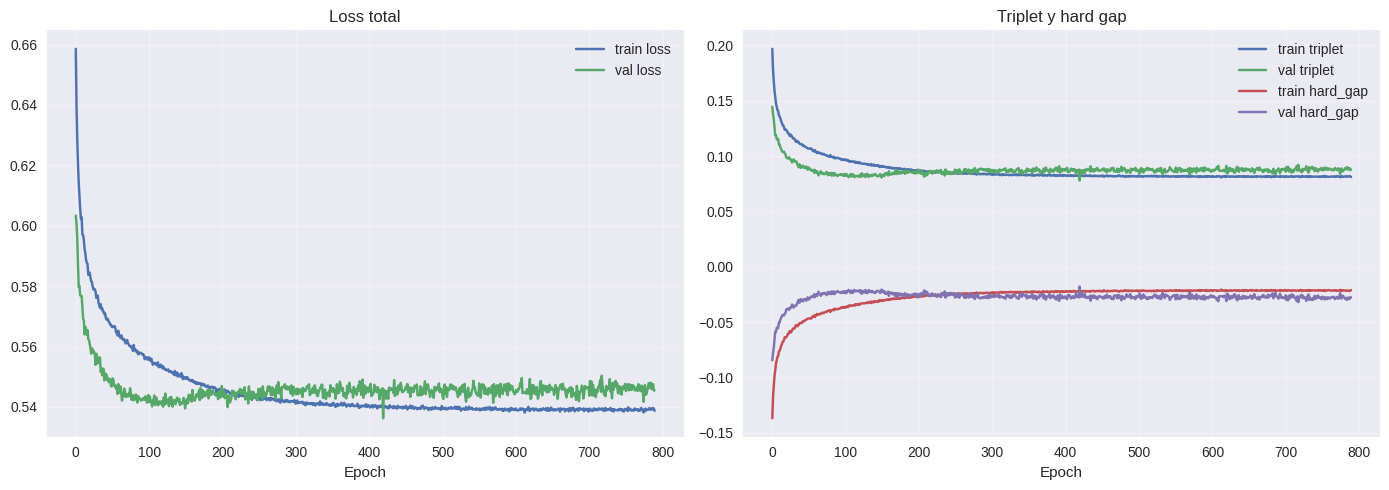

In [34]:
history_csv_candidates = []
if "HISTORY_CSV_PATH" in globals():
    history_csv_candidates.append(Path(HISTORY_CSV_PATH))
history_csv_candidates.append(OUTPUT_BASE / "training_state" / "history.csv")

events_root = OUTPUT_BASE.parent if "OUTPUT_BASE" in globals() else None
if events_root is not None and events_root.exists():
    history_csv_candidates.extend(
        sorted(
            events_root.glob("*/training_state/history.csv"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )
    )

unique_candidates = []
seen_candidates = set()
for candidate in history_csv_candidates:
    candidate = Path(candidate)
    if candidate in seen_candidates:
        continue
    seen_candidates.add(candidate)
    unique_candidates.append(candidate)

history_csv_path = next((p for p in unique_candidates if p.exists()), None)

history_current_df = pd.DataFrame(history.history) if "history" in globals() else pd.DataFrame()
if not history_current_df.empty and "epoch" not in history_current_df.columns:
    history_current_df = history_current_df.copy()
    history_current_df["epoch"] = np.arange(len(history_current_df), dtype=int)

if history_csv_path is not None:
    history_full_df = pd.read_csv(history_csv_path)
    if "epoch" not in history_full_df.columns:
        history_full_df = history_full_df.reset_index().rename(columns={"index": "epoch"})

    history_full_df = (
        history_full_df.sort_values("epoch")
        .drop_duplicates(subset=["epoch"], keep="last")
        .reset_index(drop=True)
    )

    if (
        not history_current_df.empty
        and not history_full_df.empty
        and history_current_df["epoch"].max() > history_full_df["epoch"].max()
    ):
        extra_current = history_current_df[
            history_current_df["epoch"] > history_full_df["epoch"].max()
        ]
        history_df = pd.concat([history_full_df, extra_current], ignore_index=True)
    elif not history_current_df.empty and history_full_df.empty:
        history_df = history_current_df
    else:
        history_df = history_full_df

    print(f"Usando historial completo desde {history_csv_path} ({len(history_df)} epochs)")
else:
    history_df = history_current_df
    if history_df.empty:
        raise RuntimeError(
            "No hay historial para graficar. Ejecuta entrenamiento o verifica history.csv."
        )
    print(f"Usando historial en memoria ({len(history_df)} epochs)")

x_epoch = history_df["epoch"] if "epoch" in history_df.columns else np.arange(len(history_df))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col, label in [("loss", "train loss"), ("val_loss", "val loss")]:
    if col in history_df.columns:
        axes[0].plot(x_epoch, history_df[col], label=label)
axes[0].set_title("Loss total")
axes[0].set_xlabel("Epoch")
axes[0].grid(True, alpha=0.3)
if axes[0].lines:
    axes[0].legend()

for col, label in [
    ("triplet_loss", "train triplet"),
    ("val_triplet_loss", "val triplet"),
    ("hard_gap", "train hard_gap"),
    ("val_hard_gap", "val hard_gap"),
]:
    if col in history_df.columns:
        axes[1].plot(x_epoch, history_df[col], label=label)
axes[1].set_title("Triplet y hard gap")
axes[1].set_xlabel("Epoch")
axes[1].grid(True, alpha=0.3)
if axes[1].lines:
    axes[1].legend()

plt.tight_layout()
plt.show()


## 5) Hold-out(partidas no vistas) + evaluación


In [35]:
# Bootstrap HOLD-OUT al reanudar desde checkpoint sin ejecutar todas las celdas previas.
from pathlib import Path
import json
import re
import pandas as pd
import zstandard as zstd

if "chess" not in globals():
    import chess
    import chess.pgn
    import chess.svg
if "cv2" not in globals():
    import cv2
if "np" not in globals():
    import numpy as np

def _find_notebook_path():
    candidates = []
    if "REPO_ROOT" in globals():
        candidates.append(Path(REPO_ROOT) / "labs" / "notebooks" / "110_chess_siamese.ipynb")

    cwd = Path.cwd().resolve()
    for parent in [cwd, *cwd.parents]:
        candidates.append(parent / "labs" / "notebooks" / "110_chess_siamese.ipynb")

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None

def _load_symbol_from_notebook(symbol_name):
    notebook_path = _find_notebook_path()
    if notebook_path is None:
        return False

    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    needle = f"def {symbol_name}("
    for cell in notebook.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        source = "".join(cell.get("source", []))
        if needle in source:
            exec(source, globals())
            return True
    return False

if "split_pgn_games" not in globals():
    def split_pgn_games(pgn_text):
        games = []
        current = []

        for line in pgn_text.splitlines():
            if line.startswith("[Event ") and current:
                games.append("\n".join(current).strip())
                current = []
            current.append(line)

        if current:
            games.append("\n".join(current).strip())

        return [g for g in games if g]

if "decompress_player_pgn_slice" not in globals():
    def decompress_player_pgn_slice(
        player_name,
        zst_path,
        output_dir,
        start_game_idx,
        max_games,
    ):
        output_dir.mkdir(parents=True, exist_ok=True)
        out_path = output_dir / f"{player_name}.pgn"

        dctx = zstd.ZstdDecompressor()
        with open(zst_path, "rb") as f:
            reader = dctx.stream_reader(f)
            full_text = reader.read().decode("utf-8", errors="replace")

        games = split_pgn_games(full_text)
        selected = games[start_game_idx : start_game_idx + max_games]

        with open(out_path, "w", encoding="utf-8") as f:
            f.write("\n\n".join(selected))

        return out_path, len(selected)

if "find_zst_path" not in globals():
    def find_zst_path(player_name):
        prefix = player_name[:2].lower()
        candidate = PLAYERS_DIR / prefix / f"{player_name}.pgn.zst"
        if candidate.exists():
            return candidate

        prefix_dir = PLAYERS_DIR / prefix
        if not prefix_dir.exists():
            return None

        target = f"{player_name.lower()}.pgn.zst"
        for file_path in prefix_dir.iterdir():
            if file_path.name.lower() == target:
                return file_path
        return None

def _ensure_event_dirs_with_train_players() -> List[str]:
    global OUTPUT_BASE, TRAIN_PGN_DIR, TRAIN_BOARD_DIR, TRAIN_HEAT_DIR
    global HOLDOUT_PGN_DIR, HOLDOUT_BOARD_DIR, HOLDOUT_HEAT_DIR

    def _player_dirs(board_dir: Path, heat_dir: Path) -> List[str]:
        if not board_dir.exists() or not heat_dir.exists():
            return []
        return sorted(
            d.name
            for d in board_dir.iterdir()
            if d.is_dir() and (heat_dir / d.name).is_dir()
        )

    current_players = _player_dirs(TRAIN_BOARD_DIR, TRAIN_HEAT_DIR)
    if current_players:
        return current_players

    events_root = OUTPUT_BASE.parent
    target_players = int(getattr(CONFIG, "players_count", 0)) if "CONFIG" in globals() else 0

    best_event = None
    best_players: List[str] = []
    best_score = None

    if events_root.exists():
        for event_dir in sorted(
            (d for d in events_root.iterdir() if d.is_dir()),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        ):
            train_players = _player_dirs(
                event_dir / "board_images",
                event_dir / "heatmap_images",
            )
            if not train_players:
                continue

            holdout_players = _player_dirs(
                event_dir / "holdout_board_images",
                event_dir / "holdout_heatmap_images",
            )
            has_history = (event_dir / "training_state" / "history.csv").exists()

            train_count = len(train_players)
            holdout_count = len(holdout_players)
            train_closeness = -abs(train_count - target_players) if target_players > 0 else train_count
            holdout_closeness = -abs(holdout_count - target_players) if target_players > 0 else holdout_count

            score = (
                1 if holdout_count > 0 else 0,
                1 if has_history else 0,
                train_closeness,
                holdout_closeness,
                -abs(train_count - holdout_count),
            )

            if best_score is None or score > best_score:
                best_score = score
                best_event = event_dir
                best_players = train_players

    if best_event is None or not best_players:
        return []

    OUTPUT_BASE = best_event
    TRAIN_PGN_DIR = OUTPUT_BASE / "pgn_train"
    TRAIN_BOARD_DIR = OUTPUT_BASE / "board_images"
    TRAIN_HEAT_DIR = OUTPUT_BASE / "heatmap_images"
    HOLDOUT_PGN_DIR = OUTPUT_BASE / "pgn_holdout"
    HOLDOUT_BOARD_DIR = OUTPUT_BASE / "holdout_board_images"
    HOLDOUT_HEAT_DIR = OUTPUT_BASE / "holdout_heatmap_images"

    training_state_dir = OUTPUT_BASE / "training_state"
    checkpoints_dir = training_state_dir / "checkpoints"
    globals()["TRAINING_STATE_DIR"] = training_state_dir
    globals()["CHECKPOINTS_DIR"] = checkpoints_dir
    globals()["BEST_WEIGHTS_PATH"] = checkpoints_dir / "metric_trainer_best.weights.h5"
    globals()["LAST_WEIGHTS_PATH"] = checkpoints_dir / "metric_trainer_last.weights.h5"
    globals()["HISTORY_CSV_PATH"] = training_state_dir / "history.csv"
    globals()["RUN_META_PATH"] = training_state_dir / "run_meta.json"

    print(f"Evento ajustado automáticamente a: {OUTPUT_BASE.name}")
    return best_players

recovered_players = _ensure_event_dirs_with_train_players()

if "selected_players_df" not in globals() or "player" not in selected_players_df.columns:
    if "SELECTED_PLAYERS" in globals() and len(SELECTED_PLAYERS) > 0:
        selected_players_df = pd.DataFrame({"player": SELECTED_PLAYERS})
    else:
        inferred_players = recovered_players
        if not inferred_players:
            raise RuntimeError(
                "No hay jugadores para HOLD-OUT. Ejecuta antes la celda de selección/generación TRAIN o verifica OUTPUT_BASE."
            )
        selected_players_df = pd.DataFrame({"player": inferred_players})

if "zst_path" not in selected_players_df.columns or selected_players_df["zst_path"].isna().any():
    zst_paths = selected_players_df["player"].map(find_zst_path)
    missing_players = selected_players_df.loc[zst_paths.isna(), "player"].tolist()
    if missing_players:
        raise RuntimeError(f"No se encontró .pgn.zst para: {missing_players}")
    selected_players_df = selected_players_df.copy()
    selected_players_df["zst_path"] = zst_paths.map(str)

if "SELECTED_PLAYERS" not in globals():
    SELECTED_PLAYERS = selected_players_df["player"].tolist()

if "generate_player_centric_images" not in globals():
    loaded_helpers = _load_symbol_from_notebook("board_to_rgb_array")
    loaded_generator = _load_symbol_from_notebook("generate_player_centric_images")
    if not loaded_helpers or not loaded_generator or "generate_player_centric_images" not in globals():
        raise RuntimeError(
            "No se pudo restaurar generate_player_centric_images. Ejecuta la sección 2 del notebook."
        )

print(f"Bootstrap HOLD-OUT listo: {len(selected_players_df)} jugadores")


Bootstrap HOLD-OUT listo: 10 jugadores


In [36]:
holdout_rows = []
for _, row in selected_players_df.iterrows():
    holdout_pgn, count = decompress_player_pgn_slice(
        player_name=row["player"],
        zst_path=row["zst_path"],
        output_dir=HOLDOUT_PGN_DIR,
        start_game_idx=CONFIG.games_per_player,
        max_games=CONFIG.holdout_games_per_player,
    )
    holdout_rows.append(
        {
            "player": row["player"],
            "pgn_path": str(holdout_pgn),
            "games": int(count),
        }
    )

holdout_df = pd.DataFrame(holdout_rows)
display(holdout_df)

holdout_image_rows = []
for _, row in holdout_df.iterrows():
    player = row["player"]
    print(f"Generando HOLD-OUT para {player}")

    stats = generate_player_centric_images(
        pgn_path=Path(row["pgn_path"]),
        player_name=player,
        output_board=HOLDOUT_BOARD_DIR / player,
        output_heat=HOLDOUT_HEAT_DIR / player,
        sequence_len=CONFIG.sequence_len,
        fullmove_start=CONFIG.fullmove_start,
        fullmove_end=CONFIG.fullmove_end,
        output_size=CONFIG.image_size[0],
        verbose=False,
    )
    stats["player"] = player
    holdout_image_rows.append(stats)

holdout_image_df = pd.DataFrame(holdout_image_rows)
display(holdout_image_df[["player", "games_processed", "games_skipped", "errors"]])

holdout_samples_by_player, holdout_stats_df = discover_game_samples(
    board_dir=HOLDOUT_BOARD_DIR,
    heat_dir=HOLDOUT_HEAT_DIR,
    labels=PLY_LABELS,
    players_whitelist=SELECTED_PLAYERS,
    min_samples=1,
)

display(holdout_stats_df)
HOLDOUT_SAMPLES = [
    s for per_player in holdout_samples_by_player.values() for s in per_player
]
print(f"Partidas hold-out válidas: {len(HOLDOUT_SAMPLES)}")

,player,pgn_path,games
0,Arshad_1952,/workspace/code/labs/notebooks/output/events/c...,40
1,Cash_Flexington,/workspace/code/labs/notebooks/output/events/c...,40
2,DCVNormandie1,/workspace/code/labs/notebooks/output/events/c...,40
3,Dhon128,/workspace/code/labs/notebooks/output/events/c...,40
4,ViXeR4X,/workspace/code/labs/notebooks/output/events/c...,40
5,akshay_mahfud,/workspace/code/labs/notebooks/output/events/c...,40
6,andresuribe,/workspace/code/labs/notebooks/output/events/c...,40
7,caledonianchess,/workspace/code/labs/notebooks/output/events/c...,40
8,makinali1336,/workspace/code/labs/notebooks/output/events/c...,40
9,miei_1974,/workspace/code/labs/notebooks/output/events/c...,40


Generando HOLD-OUT para Arshad_1952
Generando HOLD-OUT para Cash_Flexington
Generando HOLD-OUT para DCVNormandie1
Generando HOLD-OUT para Dhon128
Generando HOLD-OUT para ViXeR4X
Generando HOLD-OUT para akshay_mahfud
Generando HOLD-OUT para andresuribe
Generando HOLD-OUT para caledonianchess
Generando HOLD-OUT para makinali1336
Generando HOLD-OUT para miei_1974


,player,games_processed,games_skipped,errors
0,Arshad_1952,40,0,0
1,Cash_Flexington,40,0,0
2,DCVNormandie1,40,0,0
3,Dhon128,40,0,0
4,ViXeR4X,40,0,0
5,akshay_mahfud,40,0,0
6,andresuribe,40,0,0
7,caledonianchess,40,0,0
8,makinali1336,40,0,0
9,miei_1974,40,0,0


,player,games
0,Arshad_1952,40
1,Cash_Flexington,40
2,DCVNormandie1,40
3,Dhon128,40
4,ViXeR4X,40
5,akshay_mahfud,40
6,andresuribe,40
7,caledonianchess,40
8,makinali1336,40
9,miei_1974,40


Partidas hold-out válidas: 400


In [37]:
# Bootstrap EVAL al reanudar tras reinicio del kernel (sin reentrenar).
from pathlib import Path
import json
import gc
import random
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

if "tf" not in globals():
    import tensorflow as tf
from tensorflow.keras import Model, layers

if "chess" not in globals():
    import chess
    import chess.pgn
    import chess.svg

if "cv2" not in globals():
    import cv2


def _find_notebook_path():
    candidates = []
    if "REPO_ROOT" in globals():
        candidates.append(Path(REPO_ROOT) / "labs" / "notebooks" / "110_chess_siamese.ipynb")

    cwd = Path.cwd().resolve()
    for parent in [cwd, *cwd.parents]:
        candidates.append(parent / "labs" / "notebooks" / "110_chess_siamese.ipynb")

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def _load_symbol_from_notebook(symbol_name):
    notebook_path = _find_notebook_path()
    if notebook_path is None:
        return False

    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    needles = (f"def {symbol_name}(", f"class {symbol_name}")

    for cell in notebook.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        source = "".join(cell.get("source", []))
        if any(needle in source for needle in needles):
            exec(source, globals())
            return True
    return False


for symbol_name in [
    "GameSample",
    "discover_game_samples",
    "split_samples_by_player",
    "load_sequence_np",
    "build_embedding_model",
    "MetricTrainer",
]:
    if symbol_name not in globals():
        if not _load_symbol_from_notebook(symbol_name):
            raise RuntimeError(
                f"No se pudo restaurar '{symbol_name}'. Ejecuta la sección correspondiente antes de evaluar."
            )

def _ensure_event_dirs_with_train_players() -> List[str]:
    global OUTPUT_BASE, TRAIN_PGN_DIR, TRAIN_BOARD_DIR, TRAIN_HEAT_DIR
    global HOLDOUT_PGN_DIR, HOLDOUT_BOARD_DIR, HOLDOUT_HEAT_DIR

    def _player_dirs(board_dir: Path, heat_dir: Path) -> List[str]:
        if not board_dir.exists() or not heat_dir.exists():
            return []
        return sorted(
            d.name
            for d in board_dir.iterdir()
            if d.is_dir() and (heat_dir / d.name).is_dir()
        )

    current_players = _player_dirs(TRAIN_BOARD_DIR, TRAIN_HEAT_DIR)
    if current_players:
        return current_players

    events_root = OUTPUT_BASE.parent
    target_players = int(getattr(CONFIG, "players_count", 0)) if "CONFIG" in globals() else 0

    best_event = None
    best_players: List[str] = []
    best_score = None

    if events_root.exists():
        for event_dir in sorted(
            (d for d in events_root.iterdir() if d.is_dir()),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        ):
            train_players = _player_dirs(
                event_dir / "board_images",
                event_dir / "heatmap_images",
            )
            if not train_players:
                continue

            holdout_players = _player_dirs(
                event_dir / "holdout_board_images",
                event_dir / "holdout_heatmap_images",
            )
            has_history = (event_dir / "training_state" / "history.csv").exists()

            train_count = len(train_players)
            holdout_count = len(holdout_players)
            train_closeness = -abs(train_count - target_players) if target_players > 0 else train_count
            holdout_closeness = -abs(holdout_count - target_players) if target_players > 0 else holdout_count

            score = (
                1 if holdout_count > 0 else 0,
                1 if has_history else 0,
                train_closeness,
                holdout_closeness,
                -abs(train_count - holdout_count),
            )

            if best_score is None or score > best_score:
                best_score = score
                best_event = event_dir
                best_players = train_players

    if best_event is None or not best_players:
        return []

    OUTPUT_BASE = best_event
    TRAIN_PGN_DIR = OUTPUT_BASE / "pgn_train"
    TRAIN_BOARD_DIR = OUTPUT_BASE / "board_images"
    TRAIN_HEAT_DIR = OUTPUT_BASE / "heatmap_images"
    HOLDOUT_PGN_DIR = OUTPUT_BASE / "pgn_holdout"
    HOLDOUT_BOARD_DIR = OUTPUT_BASE / "holdout_board_images"
    HOLDOUT_HEAT_DIR = OUTPUT_BASE / "holdout_heatmap_images"

    training_state_dir = OUTPUT_BASE / "training_state"
    checkpoints_dir = training_state_dir / "checkpoints"
    globals()["TRAINING_STATE_DIR"] = training_state_dir
    globals()["CHECKPOINTS_DIR"] = checkpoints_dir
    globals()["BEST_WEIGHTS_PATH"] = checkpoints_dir / "metric_trainer_best.weights.h5"
    globals()["LAST_WEIGHTS_PATH"] = checkpoints_dir / "metric_trainer_last.weights.h5"
    globals()["HISTORY_CSV_PATH"] = training_state_dir / "history.csv"
    globals()["RUN_META_PATH"] = training_state_dir / "run_meta.json"

    print(f"Evento ajustado automáticamente a: {OUTPUT_BASE.name}")
    return best_players

recovered_players = _ensure_event_dirs_with_train_players()

if "SELECTED_PLAYERS" not in globals() or not SELECTED_PLAYERS:
    SELECTED_PLAYERS = recovered_players
    if not SELECTED_PLAYERS:
        raise RuntimeError(
            "No hay imágenes TRAIN para reconstruir el estado de evaluación. Verifica OUTPUT_BASE o ejecuta generación TRAIN."
        )

train_samples_by_player, train_stats_df = discover_game_samples(
    board_dir=TRAIN_BOARD_DIR,
    heat_dir=TRAIN_HEAT_DIR,
    labels=PLY_LABELS,
    players_whitelist=SELECTED_PLAYERS,
    min_samples=CONFIG.min_samples_per_player,
)
train_by_player, val_by_player, TRAIN_SAMPLES, VAL_SAMPLES = split_samples_by_player(
    samples_by_player=train_samples_by_player,
    val_fraction=CONFIG.validation_fraction,
    seed=CONFIG.seed,
)

PLAYER_TO_LABEL = {p: i for i, p in enumerate(sorted(train_by_player.keys()))}
LABEL_TO_PLAYER = {i: p for p, i in PLAYER_TO_LABEL.items()}

holdout_samples_by_player, holdout_stats_df = discover_game_samples(
    board_dir=HOLDOUT_BOARD_DIR,
    heat_dir=HOLDOUT_HEAT_DIR,
    labels=PLY_LABELS,
    players_whitelist=list(PLAYER_TO_LABEL.keys()),
    min_samples=1,
)
HOLDOUT_SAMPLES = [
    sample for per_player in holdout_samples_by_player.values() for sample in per_player
]

if "embedding_model" not in globals():
    embedding_model = build_embedding_model(
        seq_len=CONFIG.sequence_len,
        image_size=CONFIG.image_size,
        embedding_dim=CONFIG.embedding_dim,
    )

trainer = MetricTrainer(
    embedding_model=embedding_model,
    num_classes=len(PLAYER_TO_LABEL),
    margin=CONFIG.margin,
    ce_weight=CONFIG.ce_weight,
)

dummy_inputs = {
    "board_sequence": np.zeros(
        (1, CONFIG.sequence_len, CONFIG.image_size[0], CONFIG.image_size[1], 3),
        dtype=np.float32,
    ),
    "heat_sequence": np.zeros(
        (1, CONFIG.sequence_len, CONFIG.image_size[0], CONFIG.image_size[1], 1),
        dtype=np.float32,
    ),
}
_ = trainer(dummy_inputs, training=False)

checkpoint_candidates = []
for var_name in ["BEST_WEIGHTS_PATH", "LAST_WEIGHTS_PATH"]:
    if var_name in globals():
        checkpoint_candidates.append(Path(globals()[var_name]))

training_state_dir = OUTPUT_BASE / "training_state"
checkpoint_candidates.extend(
    sorted((training_state_dir / "checkpoints").glob("*.weights.h5"))
)
checkpoint_candidates.extend(sorted(training_state_dir.glob("*.weights.h5")))

events_root = OUTPUT_BASE.parent
if events_root.exists():
    checkpoint_candidates.extend(
        sorted(events_root.glob("*/training_state/checkpoints/*.weights.h5"))
    )
    checkpoint_candidates.extend(sorted(events_root.glob("*/training_state/*.weights.h5")))

deduped_candidates = []
seen = set()
for candidate in checkpoint_candidates:
    candidate = Path(candidate)
    if candidate in seen or not candidate.exists():
        continue
    seen.add(candidate)
    deduped_candidates.append(candidate)

loaded_checkpoint = None
for checkpoint_path in deduped_candidates:
    try:
        trainer.load_weights(str(checkpoint_path))
        loaded_checkpoint = checkpoint_path
        break
    except Exception:
        continue

if loaded_checkpoint is None:
    raise RuntimeError(
        "No se pudieron cargar pesos para evaluación. Revisa training_state/checkpoints o vuelve a cargar checkpoint de entrenamiento."
    )

embedding_model = trainer.embedding_model
gc.collect()

print(
    f"Bootstrap EVAL listo | TRAIN={len(TRAIN_SAMPLES)} | HOLDOUT={len(HOLDOUT_SAMPLES)} | pesos={loaded_checkpoint}"
)


W0000 00:00:1773585566.037183   33320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773585566.037464   33320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773585566.037679   33320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773585566.037950   33320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773585566.038207   33320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773585566.038520   33320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773585566.039231   33320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773585566.039618   33320 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773585566.040251   33320 gp

2026-03-15 14:39:27,912 [WARNING] Model's `__init__()` arguments contain non-serializable objects. Please implement a `get_config()` method in the subclassed Model for proper saving and loading. Defaulting to empty config.


2026-03-15 14:39:27,913 [WARNING] Model's `__init__()` arguments contain non-serializable objects. Please implement a `get_config()` method in the subclassed Model for proper saving and loading. Defaulting to empty config.


Bootstrap EVAL listo | TRAIN=1440 | HOLDOUT=400 | pesos=/workspace/code/labs/notebooks/output/events/compressed_110/training_state/checkpoints/metric_trainer_best.weights.h5


In [38]:
import gc
from typing import Dict, List, Tuple


def embed_samples_streaming(
    samples: List[GameSample],
    player_to_label: Dict[str, int],
    image_size: Tuple[int, int],
    batch_size: int = 4,
    tag: str = "SAMPLES",
) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    if not samples:
        raise RuntimeError(f"No hay muestras para {tag}.")

    emb_chunks: List[np.ndarray] = []
    label_chunks: List[np.ndarray] = []
    players: List[str] = []

    total = len(samples)
    for start in range(0, total, batch_size):
        batch = samples[start : start + batch_size]

        boards = []
        heats = []
        labels = []
        for sample in batch:
            board_seq, heat_seq = load_sequence_np(sample, image_size)
            boards.append(board_seq)
            heats.append(heat_seq)
            labels.append(player_to_label[sample.player])
            players.append(sample.player)

        boards_np = np.stack(boards).astype(np.float32)
        heats_np = np.stack(heats).astype(np.float32)
        labels_np = np.array(labels, dtype=np.int32)

        emb_batch = embedding_model.predict(
            {"board_sequence": boards_np, "heat_sequence": heats_np},
            batch_size=len(batch),
            verbose=0,
        )
        emb_chunks.append(emb_batch.astype(np.float32))
        label_chunks.append(labels_np)

        processed = min(start + batch_size, total)
        print(f"{tag}: {processed}/{total}")

        del boards_np, heats_np, labels_np, emb_batch, boards, heats, labels
        gc.collect()

    embeddings = np.vstack(emb_chunks)
    labels = np.concatenate(label_chunks)
    return embeddings, labels, players


train_embeddings, train_labels, train_players = embed_samples_streaming(
    TRAIN_SAMPLES,
    PLAYER_TO_LABEL,
    CONFIG.image_size,
    batch_size=4,
    tag="TRAIN",
)
hold_embeddings, hold_labels, hold_players = embed_samples_streaming(
    HOLDOUT_SAMPLES,
    PLAYER_TO_LABEL,
    CONFIG.image_size,
    batch_size=4,
    tag="HOLDOUT",
)

num_classes = len(PLAYER_TO_LABEL)
centroid_players = [LABEL_TO_PLAYER[i] for i in range(num_classes)]

centroids = []
for class_idx in range(num_classes):
    class_emb = train_embeddings[train_labels == class_idx]
    if class_emb.size == 0:
        raise RuntimeError(f"Sin embeddings TRAIN para clase {class_idx}.")
    centroids.append(class_emb.mean(axis=0))
centroid_matrix = np.vstack(centroids)

# Clasificación por centroide
centroid_dists = np.linalg.norm(
    hold_embeddings[:, None, :] - centroid_matrix[None, :, :],
    axis=2,
)
centroid_scores = -centroid_dists
centroid_pred = np.argmin(centroid_dists, axis=1)

acc_top1 = top_k_accuracy_score(
    hold_labels, centroid_scores, k=1, labels=np.arange(num_classes)
)
acc_top3 = top_k_accuracy_score(
    hold_labels, centroid_scores, k=min(3, num_classes), labels=np.arange(num_classes)
)

print("=" * 70)
print(f"Centroid Top-1 accuracy: {acc_top1:.2%}")
print(f"Centroid Top-3 accuracy: {acc_top3:.2%}")
print(f"Partidas hold-out evaluadas: {len(hold_labels)}")
print("=" * 70)

print("\nReporte de clasificación (centroid):\n")
print(
    classification_report(
        hold_labels,
        centroid_pred,
        labels=np.arange(num_classes),
        target_names=centroid_players,
        zero_division=0,
    )
)

# Clasificación kNN como baseline métrico adicional
knn_k = min(7, max(1, len(TRAIN_SAMPLES) // max(num_classes, 1)))
knn = KNeighborsClassifier(n_neighbors=knn_k, weights="distance", metric="euclidean")
knn.fit(train_embeddings, train_labels)
knn_pred = knn.predict(hold_embeddings)
knn_acc = accuracy_score(hold_labels, knn_pred)
print(f"kNN accuracy (k={knn_k}): {knn_acc:.2%}")


W0000 00:00:1773586344.528385   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586344.548793   33403 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586344.573677   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586344.609695   33403 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586344.638295   33403 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586344.679453   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586344.680214   33403 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586344.682506   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586344.683289   33403 gp

TRAIN: 4/1440


W0000 00:00:1773586346.153512   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586346.154325   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586346.156568   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586346.158998   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586346.161448   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586346.164488   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586346.167652   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586346.169868   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586346.172705   33394 gp

TRAIN: 8/1440


W0000 00:00:1773586347.400977   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586347.401770   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586347.403634   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586347.406575   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586347.408976   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586347.412218   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586347.415694   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586347.418520   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586347.421828   33394 gp

...

TRAIN: 32/1440


W0000 00:00:1773586356.025484   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586356.026266   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586356.028107   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586356.030028   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586356.033111   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586356.035695   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586356.039033   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586356.041571   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586356.044290   33402 gp

TRAIN: 36/1440


W0000 00:00:1773586357.493888   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586357.494489   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586357.495268   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586357.498543   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586357.501629   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586357.504748   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586357.507579   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586357.510395   33402 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773586357.513841   33402 gp

TRAIN: 40/1440
TRAIN: 44/1440
TRAIN: 48/1440
TRAIN: 52/1440
TRAIN: 56/1440
TRAIN: 60/1440
TRAIN: 64/1440
TRAIN: 68/1440
TRAIN: 72/1440
TRAIN: 76/1440
TRAIN: 80/1440
TRAIN: 84/1440
TRAIN: 88/1440
TRAIN: 92/1440
TRAIN: 96/1440
TRAIN: 100/1440
TRAIN: 104/1440
TRAIN: 108/1440
TRAIN: 112/1440
TRAIN: 116/1440
TRAIN: 120/1440
TRAIN: 124/1440
TRAIN: 128/1440
TRAIN: 132/1440
TRAIN: 136/1440
TRAIN: 140/1440
TRAIN: 144/1440
TRAIN: 148/1440
TRAIN: 152/1440
TRAIN: 156/1440
TRAIN: 160/1440
TRAIN: 164/1440
TRAIN: 168/1440
TRAIN: 172/1440
TRAIN: 176/1440
TRAIN: 180/1440
TRAIN: 184/1440
TRAIN: 188/1440
TRAIN: 192/1440
TRAIN: 196/1440
TRAIN: 200/1440
TRAIN: 204/1440
TRAIN: 208/1440
TRAIN: 212/1440
TRAIN: 216/1440
TRAIN: 220/1440
TRAIN: 224/1440
TRAIN: 228/1440
TRAIN: 232/1440
TRAIN: 236/1440
TRAIN: 240/1440
TRAIN: 244/1440
TRAIN: 248/1440
TRAIN: 252/1440
TRAIN: 256/1440
TRAIN: 260/1440
TRAIN: 264/1440
TRAIN: 268/1440
TRAIN: 272/1440
TRAIN: 276/1440
TRAIN: 280/1440
TRAIN: 284/1440
TRAIN: 288/1440
TRAIN: 

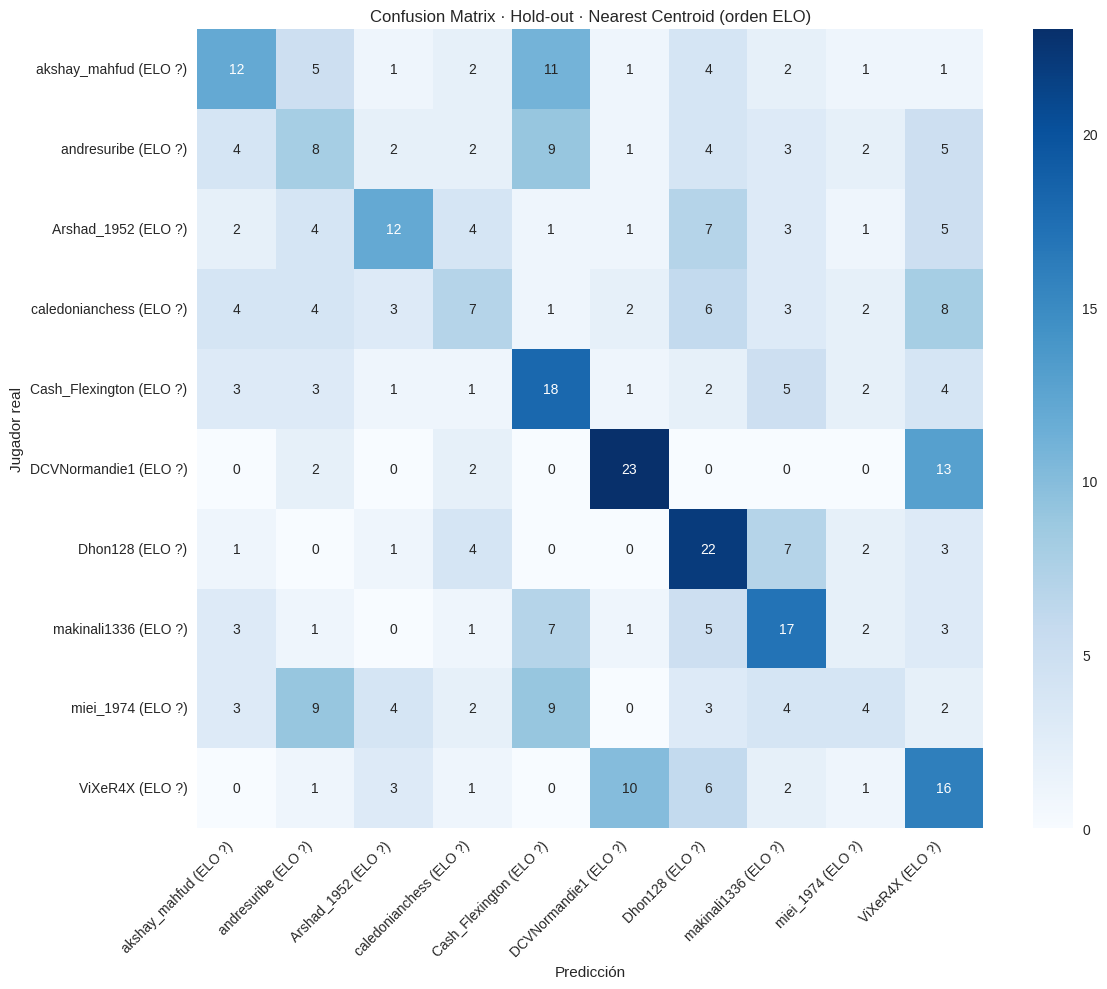

In [44]:
elo_by_player = {}

if "selected_players_df" in globals() and {"player", "elo"}.issubset(selected_players_df.columns):
    for _, row in selected_players_df[["player", "elo"]].drop_duplicates("player").iterrows():
        try:
            elo_by_player[str(row["player"])] = float(row["elo"])
        except Exception:
            continue

if "PLAYER_ELO" in globals() and isinstance(PLAYER_ELO, dict):
    for player, elo in PLAYER_ELO.items():
        try:
            elo_val = float(elo)
        except Exception:
            continue
        if not np.isnan(elo_val):
            elo_by_player[str(player)] = elo_val


def _elo_sort_key(player: str):
    elo = elo_by_player.get(player, np.nan)
    if np.isnan(elo):
        return (1, float("inf"), player.lower())
    return (0, elo, player.lower())


ordered_players = sorted(centroid_players, key=_elo_sort_key)
order_idx = [centroid_players.index(player) for player in ordered_players]

cm = confusion_matrix(
    hold_labels, centroid_pred, labels=np.arange(len(centroid_players))
)
cm_ordered = cm[np.ix_(order_idx, order_idx)]

ordered_labels = []
for player in ordered_players:
    elo = elo_by_player.get(player, np.nan)
    if np.isnan(elo):
        ordered_labels.append(f"{player} (ELO ?)")
    else:
        ordered_labels.append(f"{player} ({int(round(elo))})")

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_ordered,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ordered_labels,
    yticklabels=ordered_labels,
    ax=ax,
)
ax.set_title("Confusion Matrix · Hold-out · Nearest Centroid (orden ELO)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Jugador real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


ANÁLISIS DE DISTANCIAS · HOLD-OUT
Distancia media a centroide propio:            0.034373
Distancia media a centroide ajeno más cercano: 0.031608
Ratio own/other:                               1.0875
Margen efectivo (other-own):                   -0.002765


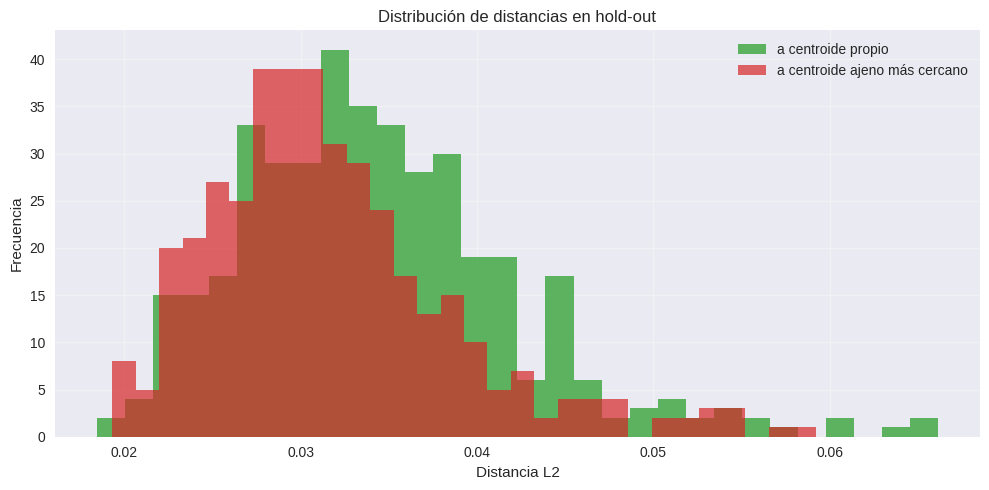

In [40]:
own_dist = centroid_dists[np.arange(len(hold_labels)), hold_labels]
mask_other = np.ones_like(centroid_dists, dtype=bool)
mask_other[np.arange(len(hold_labels)), hold_labels] = False
nearest_other = np.min(np.where(mask_other, centroid_dists, np.inf), axis=1)

ratio = float(np.mean(own_dist) / np.mean(nearest_other))
margin = float(np.mean(nearest_other) - np.mean(own_dist))

print("ANÁLISIS DE DISTANCIAS · HOLD-OUT")
print("=" * 70)
print(f"Distancia media a centroide propio:            {np.mean(own_dist):.6f}")
print(f"Distancia media a centroide ajeno más cercano: {np.mean(nearest_other):.6f}")
print(f"Ratio own/other:                               {ratio:.4f}")
print(f"Margen efectivo (other-own):                   {margin:.6f}")
print("=" * 70)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(own_dist, bins=30, alpha=0.75, label="a centroide propio", color="tab:green")
ax.hist(
    nearest_other,
    bins=30,
    alpha=0.70,
    label="a centroide ajeno más cercano",
    color="tab:red",
)
ax.set_title("Distribución de distancias en hold-out")
ax.set_xlabel("Distancia L2")
ax.set_ylabel("Frecuencia")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6) Inferencia para una partida arbitraria

En inferencia real, para una partida nueva puedes evaluar ambos lados (`white` y `black`) y quedarte con la predicción más consistente.


In [41]:
def build_single_game_tensor(
    game: chess.pgn.Game,
    side: str,
    sequence_len: int,
    fullmove_start: int,
    fullmove_end: int,
    image_size: Tuple[int, int],
) -> Tuple[np.ndarray, np.ndarray]:
    side = side.lower().strip()
    if side not in {"white", "black"}:
        raise ValueError("side debe ser 'white' o 'black'.")

    player_color = chess.WHITE if side == "white" else chess.BLACK
    moves = list(game.mainline_moves())
    selected_halfmoves = select_player_halfmoves(
        total_halfmoves=len(moves),
        player_color=player_color,
        fullmove_start=fullmove_start,
        fullmove_end=fullmove_end,
    )
    if len(selected_halfmoves) < sequence_len:
        raise RuntimeError(
            "La partida no tiene suficientes jugadas para esta configuración."
        )

    selected_halfmoves = selected_halfmoves[:sequence_len]
    decision_map = extract_decision_seconds_by_halfmove(game)

    board = game.board()
    board_states = {}
    for hm, move in enumerate(moves, start=1):
        board.push(move)
        if hm in selected_halfmoves:
            board_states[hm] = board.copy()
        if len(board_states) == len(selected_halfmoves):
            break

    boards = np.zeros(
        (1, sequence_len, image_size[0], image_size[1], 3), dtype=np.float32
    )
    heats = np.zeros(
        (1, sequence_len, image_size[0], image_size[1], 1), dtype=np.float32
    )

    expected_color_name = "white" if player_color == chess.WHITE else "black"
    for idx, hm in enumerate(selected_halfmoves):
        state = normalize_board_for_player(board_states[hm], player_color)
        rgb = board_to_rgb_array(state, size=400)
        rgb = cv2.resize(
            rgb, (image_size[1], image_size[0]), interpolation=cv2.INTER_AREA
        )
        boards[0, idx] = rgb.astype(np.float32) / 255.0

        move = moves[hm - 1]
        info = decision_map.get(hm, {})
        seconds = (
            float(info.get("seconds", 0.0))
            if info.get("color") == expected_color_name
            else 0.0
        )
        heat = build_player_move_heatmap(
            move,
            seconds,
            image_size[0],
            mirror_for_black=(player_color == chess.BLACK),
        )
        heats[0, idx, :, :, 0] = heat.astype(np.float32) / 255.0

    return boards, heats


def predict_player_from_pgn(
    pgn_path: Path,
    game_index: int = 1,
    side: str = "white",
    top_k: int = 5,
) -> pd.DataFrame:
    with open(pgn_path, "r", encoding="utf-8", errors="replace") as f:
        game = None
        for i in range(game_index):
            game = chess.pgn.read_game(f)
            if game is None:
                raise RuntimeError(f"No existe game_index={game_index} en {pgn_path}")

    boards, heats = build_single_game_tensor(
        game=game,
        side=side,
        sequence_len=CONFIG.sequence_len,
        fullmove_start=CONFIG.fullmove_start,
        fullmove_end=CONFIG.fullmove_end,
        image_size=CONFIG.image_size,
    )

    emb = embedding_model.predict(
        {"board_sequence": boards, "heat_sequence": heats},
        verbose=0,
    )[0]

    dists = np.linalg.norm(centroid_matrix - emb[None, :], axis=1)
    order = np.argsort(dists)[: max(1, top_k)]

    rows = []
    for idx in order:
        rows.append(
            {
                "rank": len(rows) + 1,
                "player": centroid_players[idx],
                "distance": float(dists[idx]),
            }
        )
    return pd.DataFrame(rows)


# Ejemplo de uso (descomenta y ajusta ruta):
# predict_player_from_pgn(Path("/ruta/a/partida.pgn"), game_index=1, side="white", top_k=5)

In [47]:
predict_player_from_pgn(Path("/workspace/code/labs/notebooks/output/events/compressed_110/pgn_tests/andresuribe.pgn"), game_index=353, side="black", top_k=5)

W0000 00:00:1773590423.708639   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773590423.709098   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773590423.709387   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773590423.710185   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773590423.711338   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773590423.712055   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773590423.713021   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773590423.713898   33394 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1773590423.714543   33394 gp

,rank,player,distance
0,1,andresuribe,0.027375
1,2,Cash_Flexington,0.030257
2,3,miei_1974,0.031331
3,4,Arshad_1952,0.031645
4,5,akshay_mahfud,0.033529


## 7) Recomendaciones para potenciar la estilometría (siguiente iteración)

1. **Ablación dirigida**: board-only vs heat-only vs fusión para medir aporte real de tiempos.
2. **Prototipos múltiples por jugador** (sub-centers) para capturar subestilos y reducir ruido intra-jugador.
3. **Calibración** de scores (temperature scaling) para convertir distancias en confianza utilizable.
4. **Open-set**: añadir umbral de rechazo para partidas fuera del conjunto de jugadores entrenados.
5. **Fusión multimodal futura**: concatenar embedding visual con embedding secuencial de jugadas SAN/UCI.


## 8) Análisis matemático y referencias

Para embeddings L2-normalizados, la distancia euclídea cumple `d in [0, 2]`.

Triplet loss (batch-hard) optimiza:

- `L = max(0, d(a,p) - d(a,n) + m)`

Con margen `m`, el objetivo práctico es empujar `E[d(a,n)] - E[d(a,p)] > m` en train **sin colapsar** la generalización en hold-out.

Indicadores útiles:

1. **Ratio de separabilidad**: `R = mean_own / mean_nearest_other` (ideal `< 1`).
2. **Margen efectivo**: `M = mean_nearest_other - mean_own` (ideal `> 0`).
3. **Top-k accuracy**: robusto cuando hay clases cercanas entre sí.

Referencias usadas para el rediseño:

- FaceNet (triplet mining): https://arxiv.org/abs/1503.03832
- In Defense of the Triplet Loss (batch-hard): https://arxiv.org/abs/1703.07737
- Sampling Matters in Deep Embedding Learning: https://arxiv.org/abs/1706.07567
- Prototypical Networks (centroides/prototipos): https://arxiv.org/abs/1703.05175
- Behavioral Stylometry in Chess (NeurIPS): https://arxiv.org/abs/2208.01366

